# Proyek Klasifikasi Gambar: Plants Classification
- **Nama:** M. Sobahus Sururin Ni'am
- **Email:** sobahusn27@gmail.com
- **ID Dicoding:** https://www.dicoding.com/users/sobahusn/

## Import Semua Packages/Library yang Digunakan

In [38]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense,
    Dropout, BatchNormalization, Rescaling, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import ( EarlyStopping, ReduceLROnPlateau, ModelCheckpoint )

## Data Preparation

### Data Loading

In [2]:
# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
files.upload()

# Konfigurasi Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download Dataset
!kaggle datasets download -d marquis03/plants-classification

# Extract Dataset
!unzip -q plants-classification.zip -d dataset

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/marquis03/plants-classification
License(s): apache-2.0
100% 1.34G/1.34G [00:14<00:00, 101MB/s]



### Data Preprocessing

#### Split Dataset

In [5]:
# Path to dataset train, test, validation

train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"
val_dir = "/content/dataset/val"

img_size = (224,224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  seed=123,
  image_size=img_size,
  batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  test_dir,
  seed=123,
  image_size=img_size,
  batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 21000 files belonging to 30 classes.
Found 6000 files belonging to 30 classes.
Found 6000 files belonging to 30 classes.


## Exploratory Data Analysis

Jumlah Class : 30
['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peperchili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweetpotatoes', 'tobacco', 'waterapple', 'watermelon']


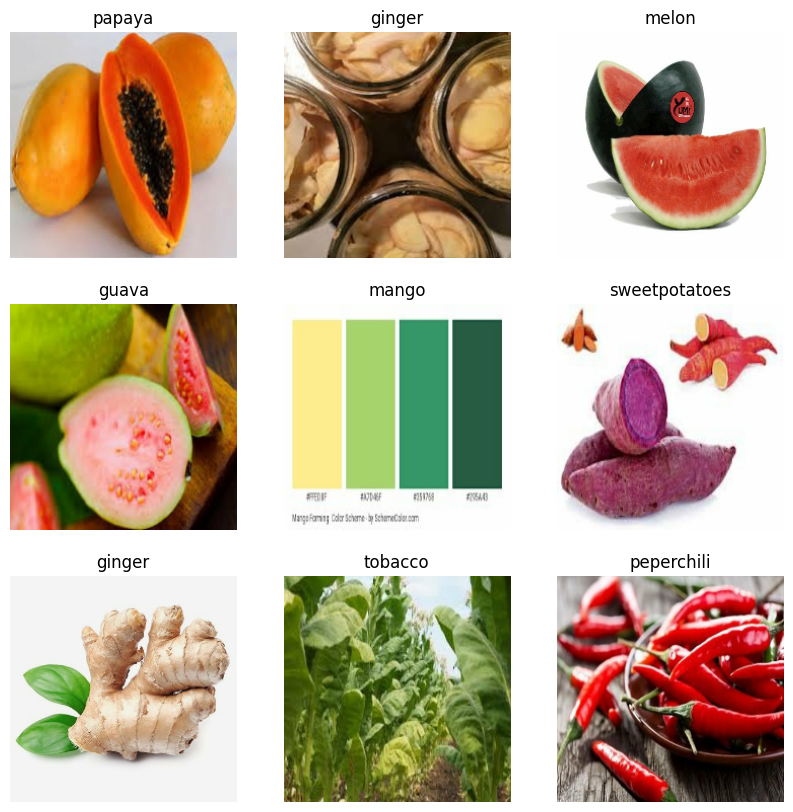

In [6]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Jumlah Class :", num_classes)
print(class_names)

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

### Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

## Modelling

In [40]:
tf.keras.backend.clear_session()

# Initialize MobileNetV2 as the base model
# Input shape adjusted to (224, 224, 3) to match the dataset's img_size
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze the base model layers

model = Sequential([
    Rescaling(1./255, input_shape=(224, 224, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

### Compile Model

In [41]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,822 (9.25 MB)

 Trainable params: 167,838 (655.62 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

None


## Callback Training

In [42]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_model.h5",
        save_best_only=True
    )
]

## Training Model

In [43]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=callbacks
)

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1469 - loss: 3.1891

657/657 ━━━━━━━━━━━━━━━━━━━━ 96s 118ms/step - accuracy: 0.2597 - loss: 2.7068 - val_accuracy: 0.6237 - val_loss: 1.5452 - learning_rate: 1.0000e-04
Epoch 2/50
655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4881 - loss: 1.8483

657/657 ━━━━━━━━━━━━━━━━━━━━ 49s 74ms/step - accuracy: 0.5193 - loss: 1.7377 - val_accuracy: 0.7085 - val_loss: 1.0873 - learning_rate: 1.0000e-04
Epoch 3/50
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5875 - loss: 1.4552

657/657 ━━━━━━━━━━━━━━━━━━━━ 80s 71ms/step - accuracy: 0.5959 - loss: 1.4209 - val_accuracy: 0.7383 - val_loss: 0.9214 - learning_rate: 1.0000e-04
Epoch 4/50
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6289 - loss: 1.2938

657/657 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.6350 - loss: 1.2705 - val_accuracy: 0.7568 - val_loss: 0.8352 - learning_rate: 1.0000e-04
Epoch 5/50
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6569 - loss: 1.1777

...

657/657 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.8659 - loss: 0.4070 - val_accuracy: 0.8353 - val_loss: 0.4832 - learning_rate: 5.0000e-05
Epoch 35/50
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8637 - loss: 0.4064

657/657 ━━━━━━━━━━━━━━━━━━━━ 81s 71ms/step - accuracy: 0.8649 - loss: 0.4002 - val_accuracy: 0.8345 - val_loss: 0.4829 - learning_rate: 5.0000e-05
Epoch 36/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8665 - loss: 0.3989

657/657 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.8664 - loss: 0.3977 - val_accuracy: 0.8350 - val_loss: 0.4816 - learning_rate: 5.0000e-05
Epoch 37/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.8685 - loss: 0.3939 - val_accuracy: 0.8348 - val_loss: 0.4825 - learning_rate: 5.0000e-05
Epoch 38/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step - accuracy: 0.8690 - loss: 0.3905 - val_accuracy: 0.8360 - val_loss: 0.4825 - learning_rate: 5.0000e-05
Epoch 39/50
656/657 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8713 - loss: 0.3838

657/657 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step - accuracy: 0.8749 - loss: 0.3787 - val_accuracy: 0.8372 - val_loss: 0.4759 - learning_rate: 2.5000e-05
Epoch 40/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8706 - loss: 0.3860

657/657 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.8720 - loss: 0.3822 - val_accuracy: 0.8372 - val_loss: 0.4745 - learning_rate: 2.5000e-05
Epoch 41/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.8770 - loss: 0.3731 - val_accuracy: 0.8363 - val_loss: 0.4763 - learning_rate: 2.5000e-05
Epoch 42/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 48s 73ms/step - accuracy: 0.8745 - loss: 0.3704 - val_accuracy: 0.8372 - val_loss: 0.4752 - learning_rate: 2.5000e-05
Epoch 43/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step - accuracy: 0.8751 - loss: 0.3670 - val_accuracy: 0.8368 - val_loss: 0.4766 - learning_rate: 1.2500e-05
Epoch 44/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.8777 - loss: 0.3649 - val_accuracy: 0.8357 - val_loss: 0.4747 - learning_rate: 1.2500e-05


## Evaluasi dan Visualisasi

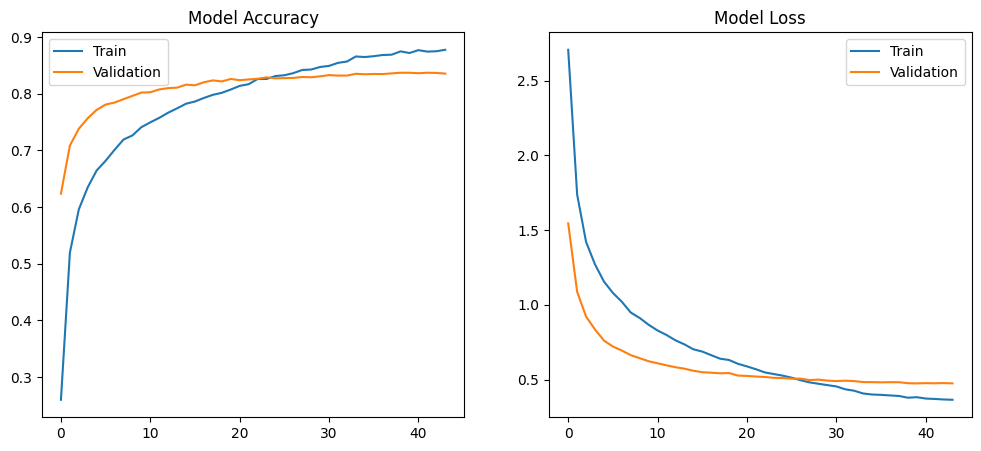

In [45]:
# Visualisasi Accuracy dan Loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.legend(["Train","Validation"])

plt.show()

## Confusion Matrix

188/188 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step


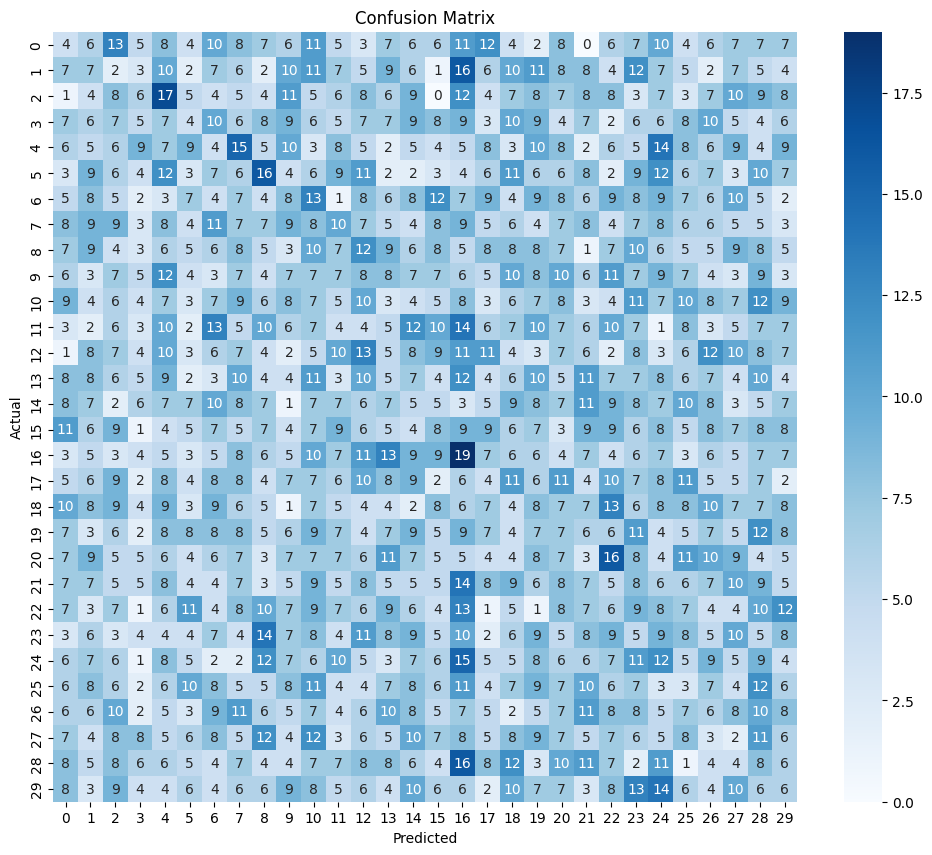

In [47]:
# Generate predictions for test_ds
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_raw = model.predict(test_ds)
y_pred = np.argmax(y_pred_raw, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", annot=True, fmt='g') # Added annot and fmt for better visualization

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [48]:
# Evaluasi Model
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy :", test_acc)
print("Test Loss :", test_loss)

188/188 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.8372 - loss: 0.4759
Test Accuracy : 0.8371666669845581
Test Loss : 0.4759102761745453


## Classification Report


In [49]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

     aloevera       0.02      0.02      0.02       200
       banana       0.04      0.04      0.04       200
      bilimbi       0.04      0.04      0.04       200
   cantaloupe       0.04      0.03      0.03       200
      cassava       0.03      0.04      0.03       200
      coconut       0.02      0.01      0.02       200
         corn       0.02      0.02      0.02       200
     cucumber       0.03      0.04      0.03       200
      curcuma       0.03      0.03      0.03       200
     eggplant       0.04      0.04      0.04       200
     galangal       0.03      0.04      0.03       200
       ginger       0.02      0.02      0.02       200
        guava       0.06      0.07      0.06       200
         kale       0.03      0.03      0.03       200
    longbeans       0.02      0.03      0.02       200
        mango       0.05      0.04      0.04       200
        melon       0.07      0.10      0.08       200
       or

## Konversi Model

### Saved Model

In [51]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 30), dtype=tf.float32, name=None)
Captures:
  135949473728272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135952024540112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135949483736528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135949484207440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135952024543184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135949483735760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135949483736144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135949483724816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135949483736336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135949483726544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13594948373556

### Konversi ke TensorFlow Lite (TFLite)

In [53]:
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
  f.write(tflite_model)

### Konversi ke TensorFlow JS (TFJS)

In [55]:
!tensorflowjs_converter \
  --input_format=tf_saved_model \
  --output_format=tfjs_graph_model \
  saved_model \
  tfjs_model

2026-04-28 16:06:45.435305: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777392405.468872   45708 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777392405.479960   45708 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777392405.523918   45708 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777392405.525603   45708 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777392405.525629   45708 computation_placer.cc:177] computation placer alr

## Inference (Optional)